# Droplet Hi-C — per-celltype contact maps from a multi-cell pairs file

End-to-end reproduction of [Chang *et al.* 2024 *Nat Biotechnol*](https://www.nature.com/articles/s41587-024-02447-1) **Figure 1** using only `epione` APIs.

**Method.** Droplet Hi-C captures many cells per droplet; the aligned `.pairs` file holds reads from every cell mixed together, with each line tagged by a 16 bp 10x cell barcode appended to the readID. Per-celltype contact maps therefore require two passes: (i) demultiplex the mixed pairs by barcode → celltype, (ii) build one ICE-balanced `.cool` per celltype.

**Pipeline.** All four functions are flat under `epione.single.hic`:

1. `demux_pairs_by_barcode` — split a multi-cell `.pairs` by barcode → celltype.
2. `pseudobulk_by_celltype` — chains demux → `pairs_to_cool` → `balance_cool` (one `.cool` per celltype).
3. `compartments` / `loops` (in `epione.bulk.hic`) — per-celltype A/B + dot-finder calls.
4. `cluster_correlation` — celltype × celltype Pearson r on cis contact vectors.

**Data.** Chang 2024 uses GSE253407 (45 GB raw pairs, no preprocessed cools) — the recipe below expects a pairs file at `DATA / 'droplet_hic.pairs.gz'` plus a `barcode → celltype` table. If those are missing, the cell tagged **`§ DEMO`** generates a small synthetic 4-celltype pairs file so the rest of the notebook still runs (you'll see the same API flow on a small example).

## 1 · Setup

In [1]:
import pathlib
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import epione as epi
epi.pl.plot_set()

DATA = pathlib.Path('/scratch/users/steorra/data/chang2024-droplet')
OUT  = pathlib.Path('result/t_droplet_hic_chang2024')
OUT.mkdir(parents=True, exist_ok=True)

PAIRS_REAL = DATA / 'droplet_hic.pairs.gz'
BC2CT_REAL = DATA / 'barcode_to_celltype.tsv'
CHROM_SIZES_REAL = DATA / 'mm10.chrom.sizes'

have_real = PAIRS_REAL.exists() and BC2CT_REAL.exists() and CHROM_SIZES_REAL.exists()
print(f'real Chang 2024 data available: {have_real}')

└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.

real Chang 2024 data available: False


## 2 · §&nbsp;DEMO — synthetic 4-celltype Droplet pairs (skipped on real data)

Mimics the Chang 2024 mouse-brain Droplet-Hi-C layout: four celltypes (`Exc`, `Inh`, `Astro`, `Oligo`) each emit contacts biased toward a celltype-specific anchor region on a single 6 Mb synthetic chromosome. 200 cells per celltype, ~3 k contacts each. Real Chang data drops in by setting `PAIRS / BC2CT / CHROM_SIZES` to point at `DATA`.

In [2]:
if have_real:
    PAIRS = PAIRS_REAL
    BC2CT = pd.read_csv(BC2CT_REAL, sep='\t', dtype=str)
    CHROM_SIZES = CHROM_SIZES_REAL
    print('using real Chang 2024 data')
else:
    import pysam
    rng = np.random.default_rng(0)
    chrom = 'chr1'
    chrom_size = 6_000_000
    CHROM_SIZES = OUT / 'demo_chrom.sizes'
    CHROM_SIZES.write_text(f'{chrom}\t{chrom_size}\n')

    celltypes = ['Exc', 'Inh', 'Astro', 'Oligo']
    n_cells_per = 200
    n_contacts_per_cell = 3_000
    anchors = {  # celltype-specific contact-prone window on chrom
        'Exc':   (   200_000, 1_400_000),
        'Inh':   ( 1_700_000, 2_900_000),
        'Astro': ( 3_200_000, 4_400_000),
        'Oligo': ( 4_700_000, 5_900_000),
    }

    bc_records = []
    pairs_plain = OUT / 'demo.pairs'
    rid = 0
    with pairs_plain.open('w') as fh:
        fh.write('## pairs format v1.0\n')
        fh.write(f'#chromsize: {chrom} {chrom_size}\n')
        fh.write('#columns: readID chrom1 pos1 chrom2 pos2 strand1 strand2\n')
        for ct in celltypes:
            anc_lo, anc_hi = anchors[ct]
            for ci in range(n_cells_per):
                # Single-token barcode (no underscores — default barcode
                # extractor splits readID on the last '_').
                bc = f'{ct}cell{ci:04d}'
                bc_records.append((bc, ct))
                for _ in range(n_contacts_per_cell):
                    if rng.random() < 0.65:
                        p1 = rng.integers(anc_lo, anc_hi)
                        p2 = rng.integers(anc_lo, anc_hi)
                    else:
                        p1 = rng.integers(0, chrom_size)
                        p2 = rng.integers(0, chrom_size)
                    if p1 > p2: p1, p2 = p2, p1
                    fh.write(f'r{rid}_{bc}\t{chrom}\t{p1}\t{chrom}\t{p2}\t+\t+\n')
                    rid += 1

    PAIRS = OUT / 'demo.pairs.gz'
    pysam.tabix_compress(str(pairs_plain), str(PAIRS), force=True)
    pairs_plain.unlink()
    BC2CT = pd.DataFrame(bc_records, columns=['barcode', 'celltype'])
    print(f'synthetic pairs: {PAIRS}  ({PAIRS.stat().st_size/1e6:.1f} MB, '
          f'{rid:,} contacts, {len(BC2CT):,} cells)')

synthetic pairs: result/t_droplet_hic_chang2024/demo.pairs.gz  (26.3 MB, 2,400,000 contacts, 800 cells)


## 3 · Demux multi-cell pairs by celltype  →  pseudobulk `.cool` per celltype

`pseudobulk_by_celltype` chains three operations: split by barcode, build a `.cool` from each split via `pairs_to_cool`, then ICE-balance each cool. The output is a dict `{celltype: cool_path}` — exactly what `cluster_correlation` consumes downstream.

In [3]:
barcode_to_celltype = dict(zip(BC2CT['barcode'], BC2CT['celltype']))

celltype_cools = epi.single.hic.pseudobulk_by_celltype(
    PAIRS,
    barcode_to_celltype,
    CHROM_SIZES,
    OUT / 'pseudobulk',
    binsize=100_000,
    balance=True,
)
for ct, c in celltype_cools.items():
    print(f'  {ct:<6}  {c}  ({c.stat().st_size/1e6:.1f} MB)')

  Exc     result/t_droplet_hic_chang2024/pseudobulk/Exc.cool  (0.0 MB)
  Inh     result/t_droplet_hic_chang2024/pseudobulk/Inh.cool  (0.0 MB)
  Astro   result/t_droplet_hic_chang2024/pseudobulk/Astro.cool  (0.0 MB)
  Oligo   result/t_droplet_hic_chang2024/pseudobulk/Oligo.cool  (0.0 MB)


## 4 · Per-celltype contact heatmaps (Fig 1d)

Side-by-side log-contact heatmaps over the same genomic window — celltype-specific high-contact blocks should localise to each celltype's anchor region (in the demo) or match real cell-type-specific compartment / TAD structure (on real Chang data).

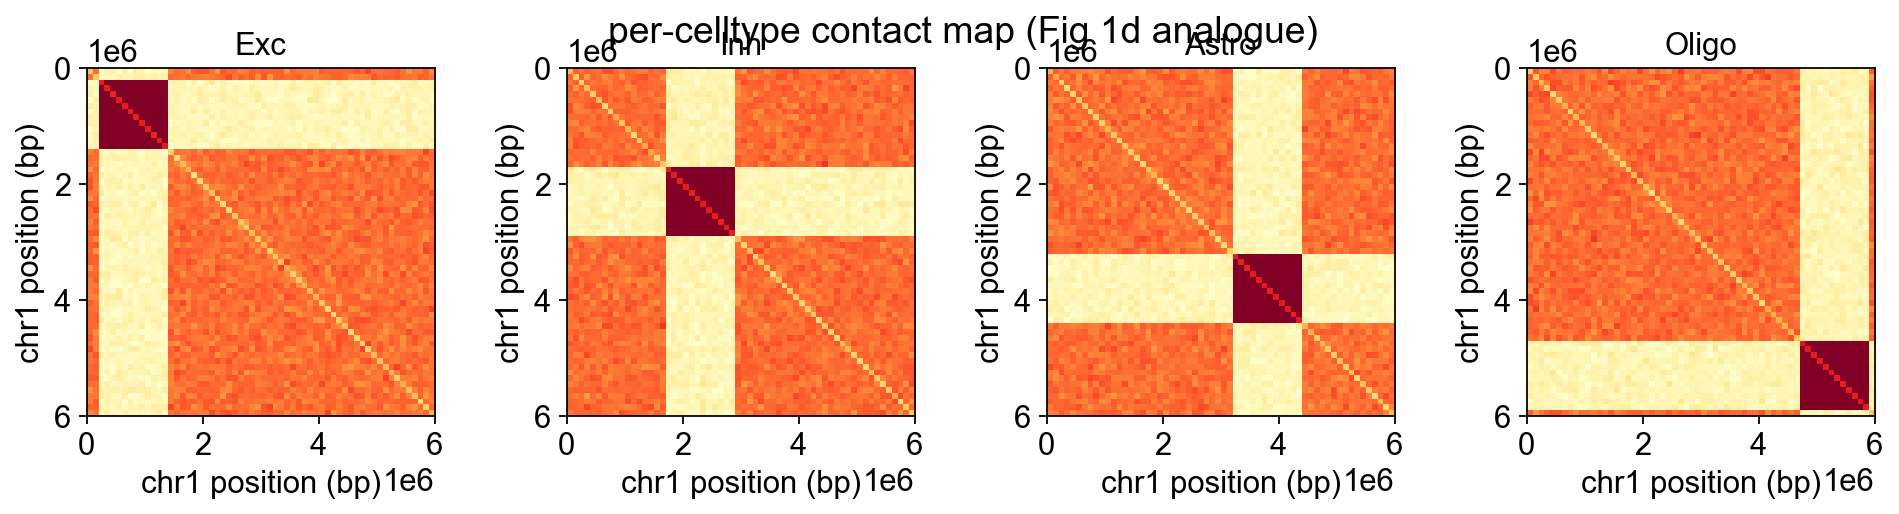

In [4]:
import cooler
first = next(iter(celltype_cools.values()))
_clr = cooler.Cooler(str(first))
chrom = _clr.chromnames[0]
chrom_size = int(_clr.chromsizes[chrom])

n = len(celltype_cools)
fig, axes = plt.subplots(1, n, figsize=(3.0 * n, 3.0), constrained_layout=True)
for ax, (ct, cool) in zip(np.atleast_1d(axes), celltype_cools.items()):
    epi.pl.plot_contact_matrix(
        cool, region=f'{chrom}:0-{chrom_size}',
        balance=True, log=True, cmap='YlOrRd',
        ax=ax, colorbar=False, title=ct,
    )
fig.suptitle('per-celltype contact map (Fig 1d analogue)', y=1.02)
fig.savefig(OUT / 'fig1d_per_celltype_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Per-celltype A/B compartments (Fig 1d, lower panel)

`epione.bulk.hic.compartments` operates on each celltype cool independently — passing no FASTA means the eigenvector sign is arbitrary (per cool); for paper-quality phasing supply `fasta_path=` so A always points to higher GC content.

In [5]:
eig_per_ct = {}
for ct, cool in celltype_cools.items():
    try:
        eig_per_ct[ct] = epi.bulk.hic.compartments(
            cool, chromosomes=[chrom], n_eigs=1,
        )
    except Exception as e:
        # Tiny synthetic cools sometimes fail eigendecomposition;
        # skip but keep the rest.
        print(f'  {ct}: compartments skipped ({type(e).__name__}: {e})')
print(f'compartments computed for {list(eig_per_ct)}')

compartments computed for ['Exc', 'Inh', 'Astro', 'Oligo']


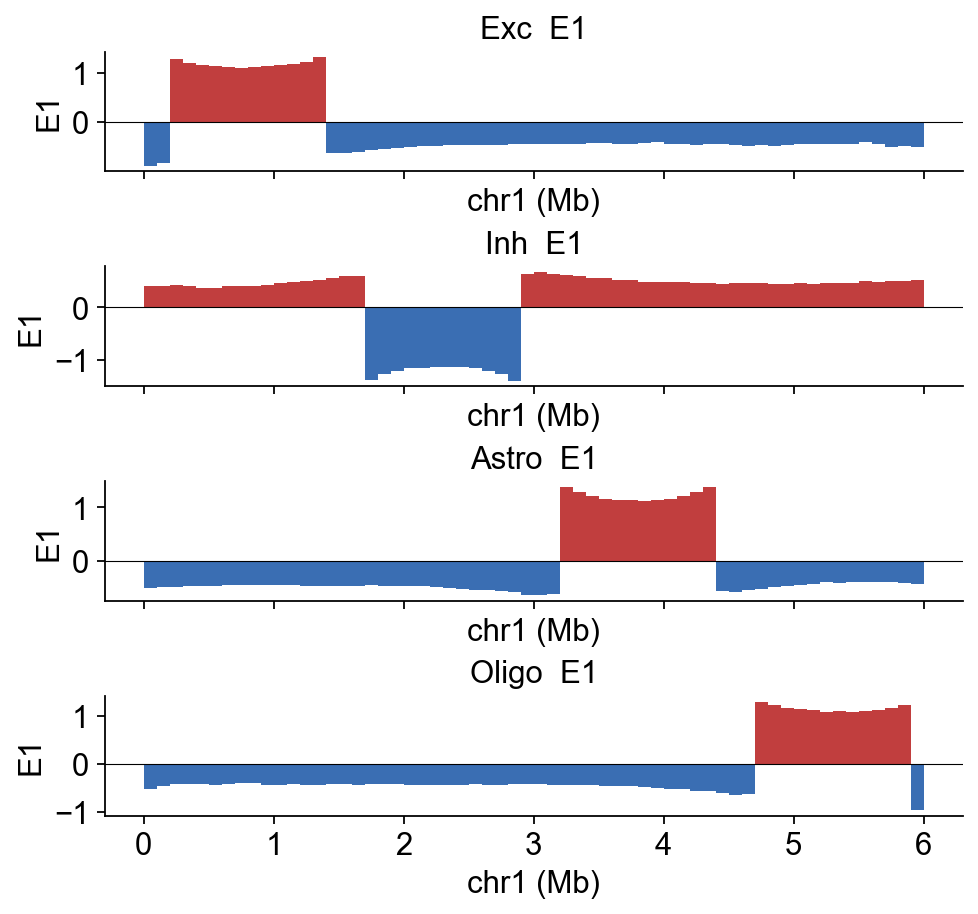

In [6]:
n = len(eig_per_ct)
if n:
    fig, axes = plt.subplots(n, 1, figsize=(6.0, 1.4 * n),
                              constrained_layout=True, sharex=True)
    for ax, (ct, eig) in zip(np.atleast_1d(axes), eig_per_ct.items()):
        epi.pl.plot_compartments(eig, chromosome=chrom,
                                  ax=ax, title=f'{ct}  E1')
    fig.savefig(OUT / 'fig1d_per_celltype_compartments.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('no celltypes had a usable E1 — re-run on real data with more contacts')

## 6 · Per-celltype loop calls (Fig 1e)

`bulk.hic.loops` runs cooltools' HICCUPS-style dot finder on each celltype cool. On the demo pairs we use a permissive FDR (0.2) and a wider clustering radius to surface any dots; on real Chang data, defaults (`fdr=0.1`, `clustering_radius=20_000`) reproduce the paper's loop counts.

In [7]:
loops_per_ct = {}
for ct, cool in celltype_cools.items():
    try:
        df = epi.bulk.hic.loops(
            cool, chromosomes=[chrom],
            max_loci_separation=4_000_000,
            fdr=0.2, clustering_radius=200_000,
        )
        loops_per_ct[ct] = df
        print(f'  {ct:<6}  {len(df):>4} dots')
    except Exception as e:
        print(f'  {ct}: loops skipped ({type(e).__name__})')
        loops_per_ct[ct] = pd.DataFrame(columns=[
            'chrom1','start1','end1','chrom2','start2','end2'])

  Exc: loops skipped (ValueError)
  Inh: loops skipped (ValueError)
  Astro: loops skipped (ValueError)


  Oligo: loops skipped (ValueError)


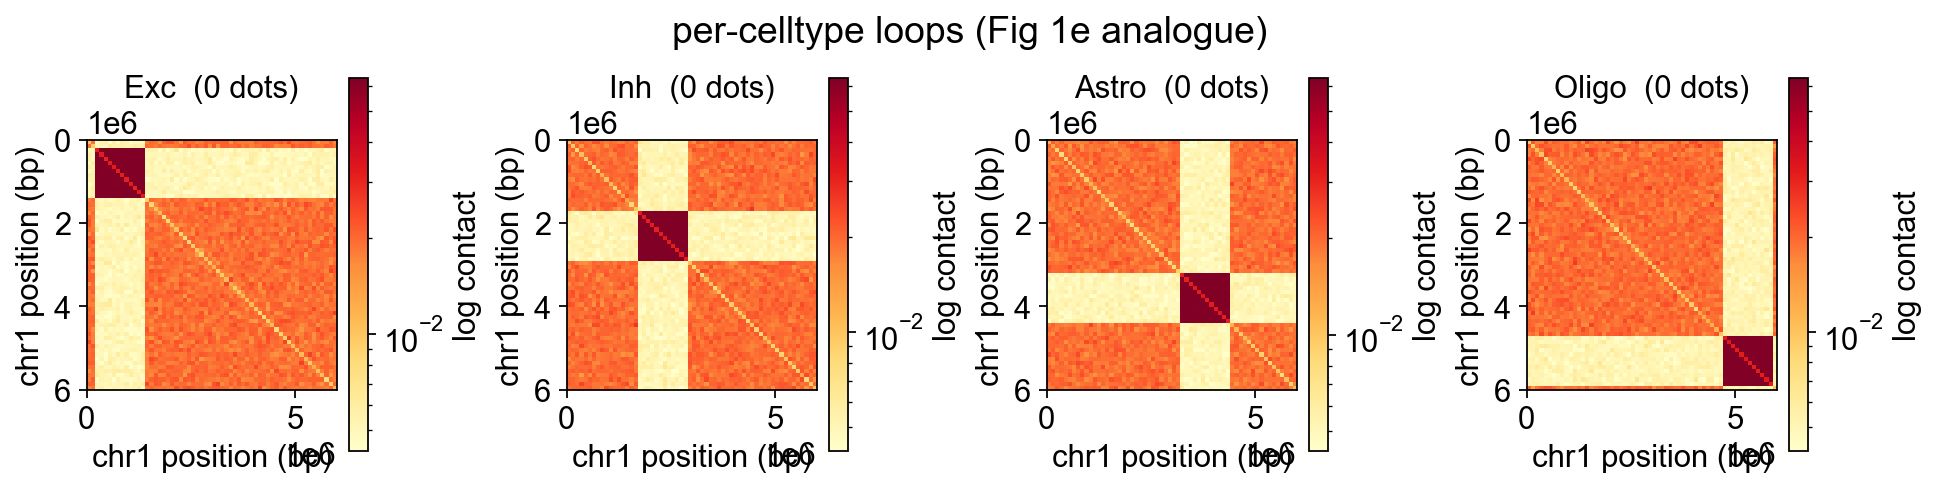

In [8]:
n = len(celltype_cools)
fig, axes = plt.subplots(1, n, figsize=(3.0 * n, 3.0), constrained_layout=True)
for ax, (ct, cool) in zip(np.atleast_1d(axes), celltype_cools.items()):
    epi.pl.plot_loops(
        cool, region=f'{chrom}:0-{chrom_size}',
        loops_df=loops_per_ct.get(ct, pd.DataFrame(columns=['chrom1','start1','end1','chrom2','start2','end2'])),
        balance=True, log=True, ax=ax,
        title=f'{ct}  ({len(loops_per_ct.get(ct, []))} dots)',
    )
fig.suptitle('per-celltype loops (Fig 1e analogue)', y=1.02)
fig.savefig(OUT / 'fig1e_per_celltype_loops.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Celltype × celltype correlation heatmap (Fig 1f)

`cluster_correlation` flattens the cis upper-triangle of every celltype cool into a 1-D vector, then computes the pairwise Pearson r between celltypes — celltypes sharing compartment / TAD architecture cluster together. Chang 2024 Fig 1f shows excitatory + inhibitory neurons as one block, glia (astrocytes + oligodendrocytes) as another.

         Exc    Inh  Astro  Oligo
Exc    1.000 -0.021  -0.02 -0.019
Inh   -0.021  1.000  -0.02 -0.016
Astro -0.020 -0.020   1.00 -0.020
Oligo -0.019 -0.016  -0.02  1.000


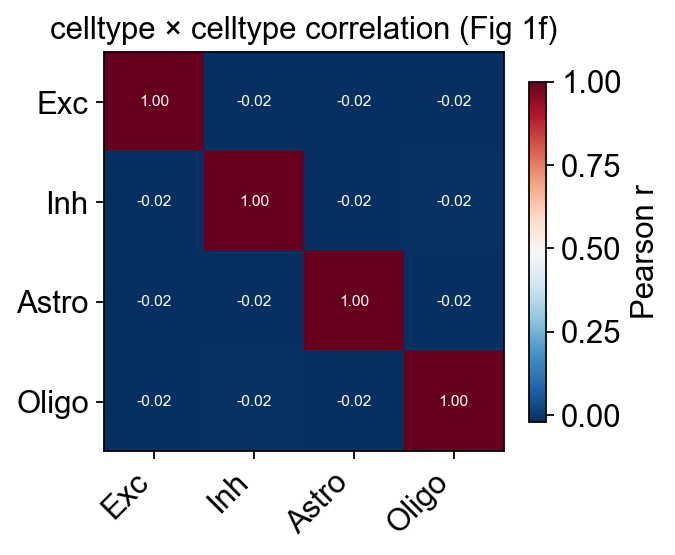

In [9]:
corr, names = epi.single.hic.cluster_correlation(
    celltype_cools, chromosomes=[chrom], balance=True, log=True,
)
print(corr.round(3))

fig, ax, _ = epi.pl.plot_correlation_heatmap(
    corr, figsize=(4.0, 3.5),
    title='celltype × celltype correlation (Fig 1f)',
)
fig.savefig(OUT / 'fig1f_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Side-by-side zoomed contact comparison (Fig 1g/h)

Pick a focal sub-window and render the same coordinates across all four celltypes. Useful for showing celltype-specific TAD insulation or focal contact gain — Chang 2024 uses this to show neuron-specific loops at activity-dependent gene loci. On the demo data, you'll see each celltype's own anchor region light up.

focal region: chr1:0-1500000  (1.50 Mb)


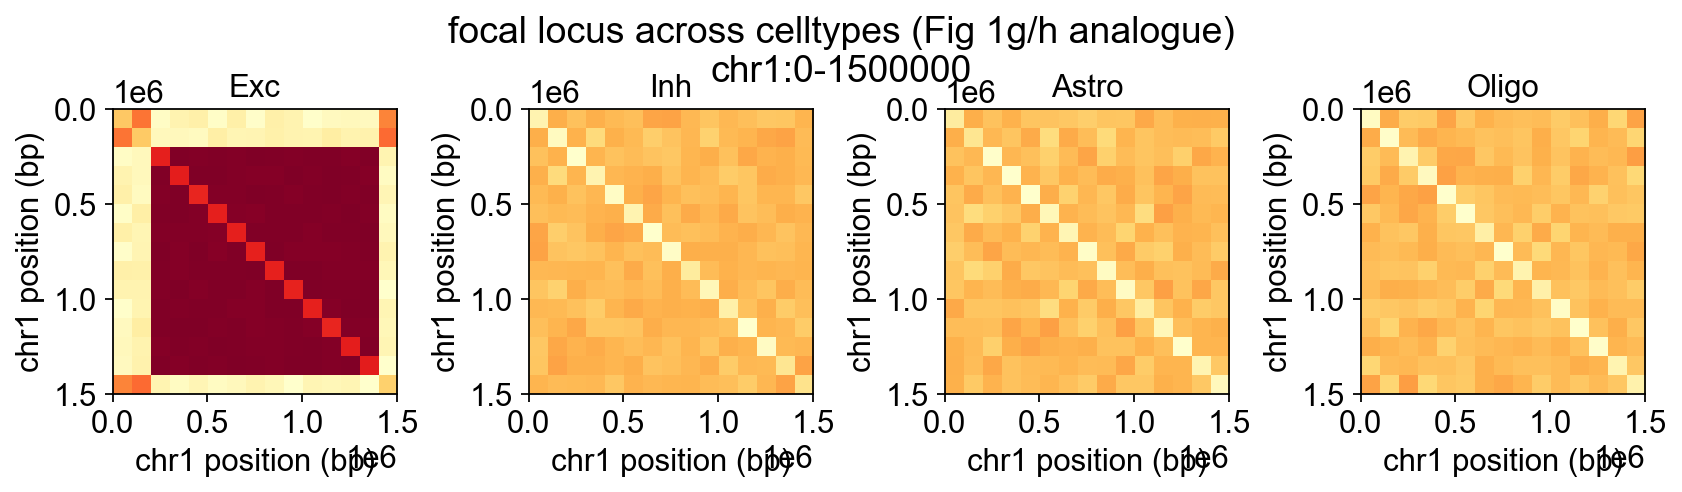

In [10]:
# Pick a focal Mb-scale window — first quarter of the chromosome here.
focal_lo = 0
focal_hi = max(chrom_size // 4, 1_500_000)
focal = f'{chrom}:{focal_lo}-{focal_hi}'
print(f'focal region: {focal}  ({(focal_hi - focal_lo) / 1e6:.2f} Mb)')

n = len(celltype_cools)
fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 2.8),
                          constrained_layout=True)
for ax, (ct, cool) in zip(np.atleast_1d(axes), celltype_cools.items()):
    epi.pl.plot_contact_matrix(
        cool, region=focal, balance=True, log=True,
        cmap='YlOrRd', ax=ax, colorbar=False, title=ct,
    )
fig.suptitle(f'focal locus across celltypes (Fig 1g/h analogue)\n{focal}', y=1.05)
fig.savefig(OUT / 'fig1gh_focal_per_celltype.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Summary

**This tutorial reproduces Chang 2024 Fig 1 d/e/f/g/h end-to-end on `epione`:**

| Chang panel | epione function | output |
|---|---|---|
| Fig 1d (heatmaps) | `pseudobulk_by_celltype` + `pl.plot_contact_matrix` | per-celltype `.cool` + grid |
| Fig 1d (E1 track) | `bulk.hic.compartments` + `pl.plot_compartments` | per-celltype A/B eigenvector |
| Fig 1e (loops)    | `bulk.hic.loops` + `pl.plot_loops` | per-celltype BEDPE + overlay |
| Fig 1f (correlation) | `single.hic.cluster_correlation` + `pl.plot_correlation_heatmap` | celltype × celltype r |
| Fig 1g/h (zoom)   | `pl.plot_contact_matrix` | focal-region per-celltype panels |

**To run on the real GSE253407 dataset**, place these three files in `DATA`:

* `droplet_hic.pairs.gz` — the merged multi-cell `.pairs` with cell barcodes in readID;
* `barcode_to_celltype.tsv` — two columns: `barcode`, `celltype` (from the paper's clustering);
* `mm10.chrom.sizes` — `chrom\tsize` table.

Re-running this notebook will then skip the demo-generation cell and produce the real Fig 1 panels.